In [1]:
"""
AMR-DINO Evaluation — Sentiment Probe
======================================
Charge un checkpoint GraphFormers-DINO, extrait les embeddings CLS
sur sentiment_amr.csv, puis calcule KNN / Linear Probe / t-SNE.
"""

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from pathlib import Path
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from transformers import BertTokenizerFast


/home/alex/malia/TER/DinoImpl/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
CHECKPOINT  = "../outputs/checkpoints/amr/checkpoint_epoch_0040.pth"
CSV_PATH    = "../dataset/sentiment_amr.csv"
BATCH_SIZE  = 32
NEIGHBOR_NUM = 21      # doit correspondre à AMRGraphDatasetGlobal
TOKEN_LENGTH = 10      # idem
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SENTIMENT_COLORS = {"positive": "#2ecc71", "neutral": "#3498db", "negative": "#e74c3c"}

print(f"Device : {DEVICE}")

Device : cuda


In [13]:
def load_backbone(checkpoint_path: str):
    """Charge le teacher backbone GraphFormers depuis un checkpoint DINO."""
    from dino.models.backbone.graphformers import GraphformersBackbone
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    print("Clés checkpoint :", list(ckpt.keys()))

    backbone = GraphformersBackbone.from_pretrained()  # init BERT weights

    # Extraire les poids du teacher backbone
    teacher_sd = ckpt["teacher_state_dict"]
    PREFIX = "backbone."
    stripped = {
        k[len(PREFIX):]: v
        for k, v in teacher_sd.items()
        if k.startswith(PREFIX)
    }

    missing, unexpected = backbone.load_state_dict(stripped, strict=False)
    if missing:
        print(f"[WARN] Missing  : {missing[:5]}")
    if unexpected:
        print(f"[WARN] Unexpected: {unexpected[:5]}")

    print(f"Backbone chargé depuis {checkpoint_path}")
    return backbone.to(DEVICE).eval()


In [4]:
def penman_to_batch(penman_strings: list, tokenizer: BertTokenizerFast) -> dict:
    """
    Convertit une liste de strings Penman en batch compatible avec
    GraphformersBackbone.forward(x) → (B, N, L).

    On utilise le même format que AMRGraphDatasetGlobal :
      - node 0 : concept racine
      - nodes 1..N : voisins encodés comme "<role> <concept>"
    """
    import penman as penman_lib

    batch_input_ids, batch_attention_mask, batch_neighbor_mask = [], [], []

    for pstr in penman_strings:
        try:
            graph = penman_lib.decode(pstr)
        except Exception:
            # Graphe invalide → placeholder zéro
            zeros = torch.zeros(NEIGHBOR_NUM + 1, TOKEN_LENGTH, dtype=torch.long)
            mask  = torch.zeros(NEIGHBOR_NUM + 1, dtype=torch.float)
            batch_input_ids.append(zeros)
            batch_attention_mask.append(zeros)
            batch_neighbor_mask.append(mask)
            continue

        node_concept = {inst.source: inst.target for inst in graph.instances()}
        root = graph.top
        root_concept = node_concept.get(root, root)

        # Voisins directs du root (depth-1)
        neighbors = []
        for src, role, tgt in graph.triples:
            if role == ":instance":
                continue
            if src == root:
                tgt_label = node_concept.get(tgt, str(tgt))
                neighbors.append(f"{role} {tgt_label}")

        # Construction du view unique (global view complet)
        all_texts = [root_concept] + neighbors
        all_texts  = all_texts[:NEIGHBOR_NUM + 1]

        encoded = tokenizer(
            all_texts,
            max_length=TOKEN_LENGTH,
            padding="max_length",
            truncation=True,
            add_special_tokens=True,
            return_tensors=None,
        )
        input_ids      = encoded["input_ids"]
        attention_mask = encoded["attention_mask"]

        real_n  = len(all_texts)
        total_n = NEIGHBOR_NUM + 1
        pad_n   = total_n - real_n
        pad_row = [[0] * TOKEN_LENGTH] * pad_n

        input_ids      = input_ids + pad_row
        attention_mask = attention_mask + pad_row
        neighbor_mask  = [1.0] * real_n + [0.0] * pad_n

        batch_input_ids.append(torch.tensor(input_ids,      dtype=torch.long))
        batch_attention_mask.append(torch.tensor(attention_mask, dtype=torch.long))
        batch_neighbor_mask.append(torch.tensor(neighbor_mask,   dtype=torch.float))

    return {
        "input_ids":      torch.stack(batch_input_ids),      # (B, N, L)
        "attention_mask": torch.stack(batch_attention_mask),  # (B, N, L)
        "neighbor_mask":  torch.stack(batch_neighbor_mask),   # (B, N)
    }

In [5]:

def extract_embeddings(backbone: nn.Module, penman_strings: list) -> np.ndarray:
    tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
    all_embeddings = []

    for i in tqdm(range(0, len(penman_strings), BATCH_SIZE), desc="Extracting embeddings"):
        batch_penmans = penman_strings[i:i+BATCH_SIZE]
        batch = penman_to_batch(batch_penmans, tokenizer)

        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with torch.no_grad():
            embeddings = backbone(batch)  # (B, D) via GraphformersBackbone.forward()

        all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)  # (N, D)


In [6]:
def knn_eval(embeddings: np.ndarray, labels: np.ndarray) -> dict:
    X_tr, X_te, y_tr, y_te = train_test_split(
        embeddings, labels, test_size=0.2, random_state=42, stratify=labels
    )
    results = {}
    print("\n── KNN ─────────────────────────────────────────")
    for k in [5, 10, 20]:
        knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
        knn.fit(X_tr, y_tr)
        acc = knn.score(X_te, y_te)
        results[f"knn_k{k}"] = acc
        print(f"  k={k:2d}  →  acc = {acc:.4f}")
    print(f"  baseline aléatoire  →  acc ≈ {1/3:.4f}")
    return results

In [7]:
def linear_probe(embeddings: np.ndarray, labels: np.ndarray, label_names) -> dict:
    X_tr, X_te, y_tr, y_te = train_test_split(
        embeddings, labels, test_size=0.2, random_state=42, stratify=labels
    )
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    clf.fit(X_tr, y_tr)
    acc = clf.score(X_te, y_te)

    print("\n── Linear Probe ────────────────────────────────")
    print(f"  accuracy = {acc:.4f}")
    print(classification_report(y_te, clf.predict(X_te), target_names=label_names))
    return {"linear_probe_acc": acc}


In [18]:
def tsne_plot(embeddings: np.ndarray, sentiments: np.ndarray, checkpoint_name: str) -> None:
    print("\n── t-SNE (peut prendre ~1 min) ─────────────────")
    coords = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(embeddings)
    fig, ax = plt.subplots(figsize=(10, 8))
    for label, color in SENTIMENT_COLORS.items():
        mask = sentiments == label
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=color, label=label, alpha=0.5, s=15, linewidths=0)

    ax.legend(markerscale=2, fontsize=12)
    ax.set_title(f"t-SNE — AMR-DINO embeddings\n{checkpoint_name}", fontsize=13)
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()

    out = f"tsne_{Path(checkpoint_name).stem}.png"
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"  Sauvegardé → {out}")

In [9]:
df = pd.read_csv(CSV_PATH)
penman_strings = df["penman_amr"].tolist()
sentiments_str = df["sentiment"].values

In [10]:
le = LabelEncoder()
labels = le.fit_transform(sentiments_str)
print(f"Classes       : {le.classes_}")
print(f"Distribution  : {np.bincount(labels)}")
print(f"Échantillons  : {len(labels)}")


Classes       : ['negative' 'neutral' 'positive']
Distribution  : [103 139 111]
Échantillons  : 353


In [25]:
backbone = load_backbone(CHECKPOINT)

Clés checkpoint : ['epoch', 'iteration', 'student_state_dict', 'teacher_state_dict', 'optimizer_state_dict', 'dino_loss_center', 'config', 'metrics', 'timestamp', 'history', 'wandb_run_id', 'scheduler_state_dict']
Loaded 196/203 parameter tensors from bert-base-uncased
Backbone chargé depuis ../outputs/checkpoints/amr/checkpoint_epoch_0040.pth


In [26]:
embeddings = extract_embeddings(backbone, penman_strings)


Extracting embeddings: 100%|██████████| 12/12 [00:01<00:00,  6.03it/s]


In [43]:
def build_bert_text(penman_str: str) -> str:
    """
    Reconstruit le même contenu textuel que penman_to_batch()
    mais comme une string plate pour BERT.
    Format : "root_concept :REL neighbor1 :REL neighbor2 ..."
    """
    import penman as penman_lib
    try:
        graph = penman_lib.decode(penman_str)
        node_concept = {i.source: i.target for i in graph.instances()}
        root = graph.top
        root_concept = node_concept.get(root, root)

        neighbors = []
        for src, role, tgt in graph.triples:
            if role == ":instance" or src != root:
                continue
            tgt_label = node_concept.get(tgt, str(tgt))
            neighbors.append(f"{role} {tgt_label}")

        return root_concept + " " + " ".join(neighbors)
    except Exception:
        return ""

def extract_bert_embeddings(penman_strings: list) -> np.ndarray:
    from transformers import BertModel, BertTokenizerFast

    tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
    bert = BertModel.from_pretrained("bert-base-uncased").to(DEVICE).eval()

    # Même contenu textuel que DINO, encodé comme string plate
    texts = [build_bert_text(p) for p in penman_strings]

    all_embs = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="BERT baseline"):
        batch = texts[i:i+BATCH_SIZE]
        enc = tokenizer(
            batch, max_length=TOKEN_LENGTH * (NEIGHBOR_NUM + 1),
            padding=True, truncation=True, return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            out = bert(**enc)
        all_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())

    return np.vstack(all_embs)


Embeddings shape  : (353, 768)
Norme moyenne     : 13.1620
Norme std         : 1.3118

── KNN ─────────────────────────────────────────
  k= 5  →  acc = 0.3099
  k=10  →  acc = 0.4225
  k=20  →  acc = 0.3803
  baseline aléatoire  →  acc ≈ 0.3333

── Linear Probe ────────────────────────────────
  accuracy = 0.4225
              precision    recall  f1-score   support

    negative       1.00      0.05      0.09        21
     neutral       0.42      0.89      0.57        28
    positive       0.40      0.18      0.25        22

    accuracy                           0.42        71
   macro avg       0.61      0.37      0.30        71
weighted avg       0.58      0.42      0.33        71



BERT baseline: 100%|██████████| 12/12 [00:01<00:00, 11.56it/s]



── BERT brut (baseline contrôle) ───────────────

── Linear Probe ────────────────────────────────
  accuracy = 0.3944
              precision    recall  f1-score   support

    negative       0.38      0.52      0.44        21
     neutral       0.42      0.39      0.41        28
    positive       0.38      0.27      0.32        22

    accuracy                           0.39        71
   macro avg       0.39      0.40      0.39        71
weighted avg       0.40      0.39      0.39        71


── t-SNE (peut prendre ~1 min) ─────────────────


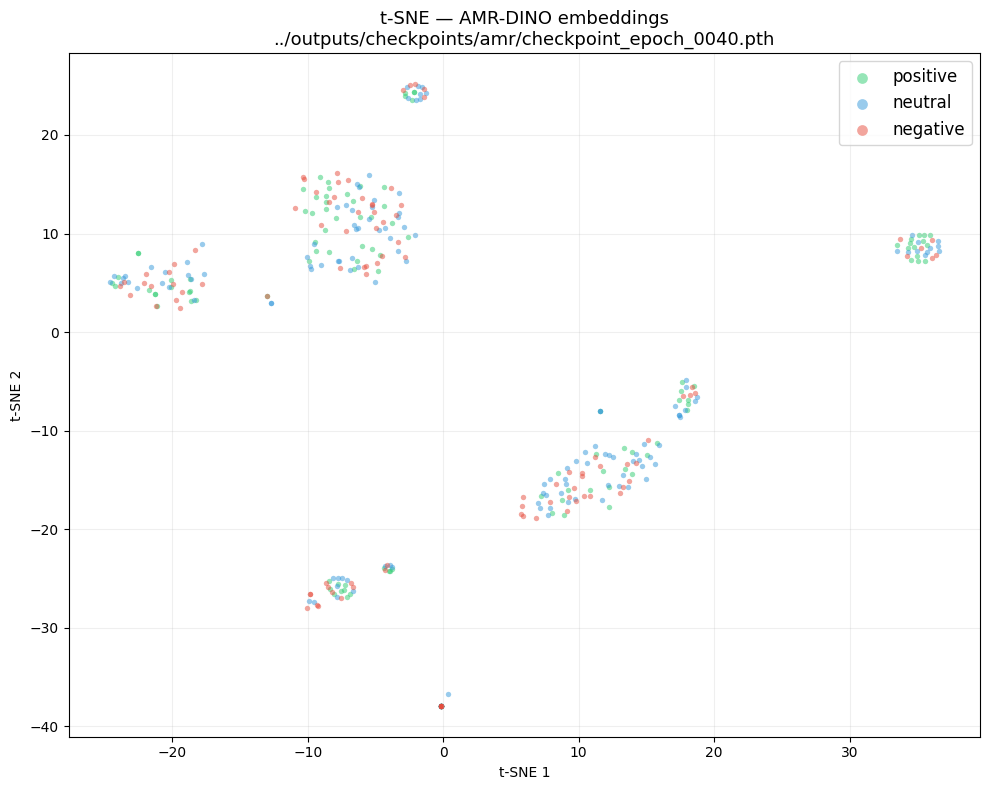

  Sauvegardé → tsne_checkpoint_epoch_0040.png

── Résumé ──────────────────────────────────────
  knn_k5                    0.3099
  knn_k10                   0.4225
  knn_k20                   0.3803
  linear_probe_acc          0.4225
  baseline_random           0.3333


In [ ]:
print(f"\nEmbeddings shape  : {embeddings.shape}")
print(f"Norme moyenne     : {np.linalg.norm(embeddings, axis=1).mean():.4f}")
print(f"Norme std         : {np.linalg.norm(embeddings, axis=1).std():.4f}")

knn_results   = knn_eval(embeddings, labels)
probe_results = linear_probe(embeddings, labels, le.classes_)
bert_embeddings = extract_bert_embeddings(df["penman_amr"].tolist())
tsne_plot(embeddings, sentiments_str, CHECKPOINT)


print("\n── Résumé ──────────────────────────────────────")
for k, v in {**knn_results, **probe_results}.items():
    print(f"  {k:<25} {v:.4f}")
print(f"  {'baseline_random':<25} {1/3:.4f}")

In [28]:
"""
Extraction de labels structurels depuis les Penman strings.
Produit un CSV enrichi avec 5 propriétés calculables automatiquement.
"""

import penman
import pandas as pd
import numpy as np
from collections import deque

In [29]:

def graph_depth(graph: penman.Graph) -> int:
    """Profondeur max depuis le root (BFS)."""
    root = graph.top
    node_concept = {i.source: i.target for i in graph.instances()}
    edges = {}  # src → [tgt, ...]
    for src, role, tgt in graph.triples:
        if role == ":instance" or tgt not in node_concept:
            continue
        edges.setdefault(src, []).append(tgt)

    visited = {root}
    queue = deque([(root, 0)])
    max_depth = 0
    while queue:
        node, depth = queue.popleft()
        max_depth = max(max_depth, depth)
        for child in edges.get(node, []):
            if child not in visited:
                visited.add(child)
                queue.append((child, depth + 1))
    return max_depth


def node_count(graph: penman.Graph) -> int:
    """Nombre de nœuds (instances) dans le graphe."""
    return len(list(graph.instances()))


def has_negation(graph: penman.Graph) -> int:
    """1 si le graphe contient :polarity -, 0 sinon."""
    return int(any(
        role == ":polarity" and str(tgt) == "-"
        for _, role, tgt in graph.triples
    ))


def has_interrogative(graph: penman.Graph) -> int:
    """1 si le graphe contient :mode interrogative ou imperative."""
    return int(any(
        role == ":mode" and str(tgt) in ("interrogative", "imperative")
        for _, role, tgt in graph.triples
    ))


def arg_count(graph: penman.Graph) -> int:
    """Nombre de relations :ARGx dans le graphe."""
    return sum(
        1 for _, role, _ in graph.triples
        if role.startswith(":ARG")
    )

In [30]:
def extract_structural_labels(penman_strings: list) -> pd.DataFrame:
    records = []
    for i, pstr in enumerate(penman_strings):
        try:
            g = penman.decode(pstr)
            records.append({
                "idx":             i,
                "depth":           graph_depth(g),
                "node_count":      node_count(g),
                "has_negation":    has_negation(g),
                "has_interrogative": has_interrogative(g),
                "arg_count":       arg_count(g),
            })
        except Exception:
            records.append({
                "idx": i, "depth": None, "node_count": None,
                "has_negation": None, "has_interrogative": None, "arg_count": None,
            })
    return pd.DataFrame(records)

In [31]:
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, r2_score
import torch
import numpy as np

In [39]:


def eval_structural_task(
    embeddings: np.ndarray,
    labels: np.ndarray,
    task_name: str,
    task_type: str = "classification",  # "classification" ou "regression"
    bert_embeddings: np.ndarray = None,
):
    """Compare DINO vs BERT brut sur une tâche structurelle."""

    # Drop NaN
    valid = pd.notna(labels)
    emb   = embeddings[valid]
    lab   = np.array(labels[valid])

    print(f"\n{'─'*50}")
    print(f"  Tâche : {task_name}  ({task_type})")
    print(f"  Échantillons valides : {valid.sum()}")
    if task_type == "classification":
        unique, counts = np.unique(lab, return_counts=True)
        for u, c in zip(unique, counts):
            print(f"    classe {u} : {c} ({c/len(lab)*100:.1f}%)")

    def run_probe(X, y, name):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, random_state=42,
            stratify=y if task_type == "classification" else None
        )
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        if task_type == "classification":
            clf = LogisticRegression(max_iter=1000, random_state=42)
            clf.fit(X_tr, y_tr)
            acc = clf.score(X_te, y_te)
            print(f"\n  [{name}] accuracy = {acc:.4f}")
            print(classification_report(y_te, clf.predict(X_te), zero_division=0))
            return acc
        else:
            reg = Ridge()
            reg.fit(X_tr, y_tr)
            r2 = r2_score(y_te, reg.predict(X_te))
            print(f"\n  [{name}] R² = {r2:.4f}")
            return r2

    dino_score = run_probe(emb, lab, "DINO AMR")

    if bert_embeddings is not None:
        bert_emb = bert_embeddings[valid]
        bert_score = run_probe(bert_emb, lab, "BERT brut")
        delta = dino_score - bert_score
        sign = "✓ DINO > BERT" if delta > 0.02 else ("✗ BERT > DINO" if delta < -0.02 else "≈ équivalent")
        print(f"\n  Delta DINO - BERT : {delta:+.4f}  {sign}")


In [ ]:
df = pd.read_csv(CSV_PATH)
penman_strings = df["penman_amr"].tolist()

print("Extraction des labels structurels...")
struct_df = extract_structural_labels(penman_strings)
print(struct_df.describe())

# Discrétiser depth et node_count en bins pour classification
struct_df["depth_bin"] = pd.qcut(
    struct_df["depth"].dropna(), q=3,
    labels=["shallow", "medium", "deep"]
).reindex(struct_df.index)

struct_df["size_bin"] = pd.qcut(
    struct_df["node_count"].dropna(), q=3,
    labels=["small", "medium", "large"]
).reindex(struct_df.index)

# On suppose que embeddings et bert_embeddings sont déjà en mémoire
# (calculés dans le notebook précédent)
tasks = [
    ("depth_bin",        "Profondeur (bins)",      "classification"),
    ("size_bin",         "Taille graphe (bins)",   "classification"),
    ("has_negation",     "Négation",               "classification"),
    ("has_interrogative","Mode (interrog/imper)",  "classification"),
    ("arg_count",        "Nb ARGs",                "regression"),
    ("node_count",       "Nb nœuds",               "regression"),
]
for col, name, ttype in tasks:
    labels_task = struct_df[col].values
    eval_structural_task(
        embeddings=embeddings,          # DINO embeddings déjà calculés
        labels=labels_task,
        task_name=name,
        task_type=ttype,
        bert_embeddings=bert_embeddings  # BERT embeddings déjà calculés
    )

Missing target: ( m / multi-sentence :snt1  ( g / get-01 :ARG0  ( i / i ) :ARG1  ( o / out-03 :ARG1 i :ARG2  ( c / class ) ) :time  ( d /  दिनांक :ARG1 10:50 ) ) :snt2  ( h / hope-01 :ARG0 i :ARG1  ( m2  / make-01 :ARG0 i :ARG1  ( i2  / it ) ) ) :discourse-marker "haaaw" :discourse-marker "well" )
Missing target: ( m / multi-sentence :snt1  ( a / and :op1  ( u / up-02 :ARG1  ( i / i ) :mod  ( j / just ) ) :op2  ( t / time :quant 12:43 ) ) :snt2  ( l / lazy :degree  ( s / so ) :domain i ) :snt3  ( t2  / thank-01 :ARG0 i :ARG1  ( p / person :name  ( n / name :op1 "god" ) ) :ARG1-of  ( c / cause-01 :ARG0  ( h / holiday :domain  ( b / bank ) ) ) ) )


Extraction des labels structurels...
              idx       depth  node_count  has_negation  has_interrogative  \
count  353.000000  331.000000  331.000000    331.000000         331.000000   
mean   176.000000    2.972810   10.353474      0.184290           0.054381   
std    102.046558    1.277729    5.344962      0.388308           0.227111   
min      0.000000    0.000000    1.000000      0.000000           0.000000   
25%     88.000000    2.000000    6.000000      0.000000           0.000000   
50%    176.000000    3.000000   10.000000      0.000000           0.000000   
75%    264.000000    4.000000   14.000000      0.000000           0.000000   
max    352.000000    6.000000   24.000000      1.000000           1.000000   

        arg_count  
count  331.000000  
mean     5.752266  
std      4.102359  
min      0.000000  
25%      3.000000  
50%      5.000000  
75%      8.000000  
max     18.000000  


AttributeError: 'NoneType' object has no attribute 'shape'